# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Heart Disease Dataset](https://www.kaggle.com/datasets/shyamnadhs/heart-disease-prediction-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('disease_prediction.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


## last Five row

In [4]:
df.tail()

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
995,996,24,Male,105,237,86,86,30.9,69,Yes,Yes,Medium,No,No
996,997,40,Male,120,219,133,72,34.3,92,Yes,Yes,Medium,No,No
997,998,44,Female,114,273,114,74,36.0,76,No,No,Low,No,Yes
998,999,31,Male,95,231,130,72,28.2,81,Yes,Yes,Medium,Yes,No
999,1000,83,Male,109,256,103,86,30.3,64,Yes,Yes,High,No,Yes


## Shape of our dataset

In [5]:
df.shape

(1000, 14)

## List out all columns

In [6]:
df.columns

Index(['patient_id', 'age', 'gender', 'glucose_mg_dl', 'cholesterol_mg_dl',
       'systolic_bp', 'diastolic_bp', 'bmi', 'heart_rate', 'smoking',
       'alcohol_consumption', 'physical_activity', 'family_history',
       'disease'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

patient_id               int64
age                      int64
gender                  object
glucose_mg_dl            int64
cholesterol_mg_dl        int64
systolic_bp              int64
diastolic_bp             int64
bmi                    float64
heart_rate               int64
smoking                 object
alcohol_consumption     object
physical_activity       object
family_history          object
disease                 object
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           1000 non-null   int64  
 1   age                  1000 non-null   int64  
 2   gender               1000 non-null   object 
 3   glucose_mg_dl        1000 non-null   int64  
 4   cholesterol_mg_dl    1000 non-null   int64  
 5   systolic_bp          1000 non-null   int64  
 6   diastolic_bp         1000 non-null   int64  
 7   bmi                  1000 non-null   float64
 8   heart_rate           1000 non-null   int64  
 9   smoking              1000 non-null   object 
 10  alcohol_consumption  1000 non-null   object 
 11  physical_activity    1000 non-null   object 
 12  family_history       1000 non-null   object 
 13  disease              1000 non-null   object 
dtypes: float64(1), int64(7), object(6)
memory usage: 109.5+ KB


## Check Null Value

In [9]:
df.isnull().sum()

patient_id             0
age                    0
gender                 0
glucose_mg_dl          0
cholesterol_mg_dl      0
systolic_bp            0
diastolic_bp           0
bmi                    0
heart_rate             0
smoking                0
alcohol_consumption    0
physical_activity      0
family_history         0
disease                0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,patient_id,age,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,51.190000,104.163000,210.014000,123.893000,81.032000,26.093000,75.968000
std,288.819436,19.847514,25.076508,39.749111,18.701211,9.969974,4.758282,9.902982
min,1.000000,18.000000,30.000000,89.000000,67.000000,49.000000,16.000000,47.000000
25%,250.750000,33.000000,87.000000,183.000000,111.000000,74.000000,22.900000,70.000000
50%,500.500000,52.500000,105.000000,210.500000,124.000000,81.000000,26.000000,76.000000
75%,750.250000,69.000000,121.000000,235.250000,135.000000,88.000000,29.300000,83.000000
max,1000.000000,85.000000,184.000000,339.000000,195.000000,113.000000,41.500000,114.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

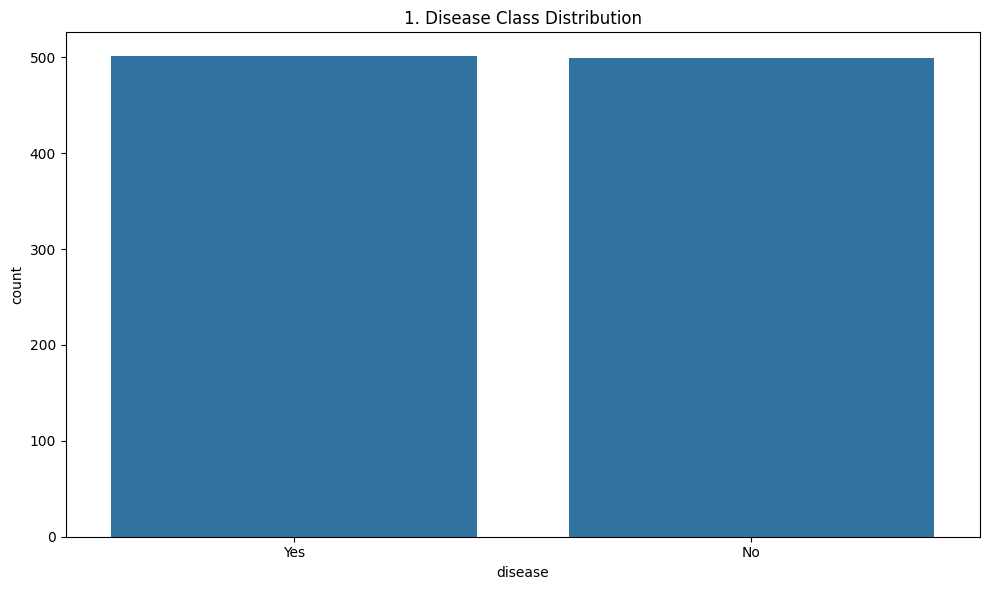

In [13]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='disease')
plt.title(f'{plot_no}. Disease Class Distribution')
show_fig()
plot_no += 1

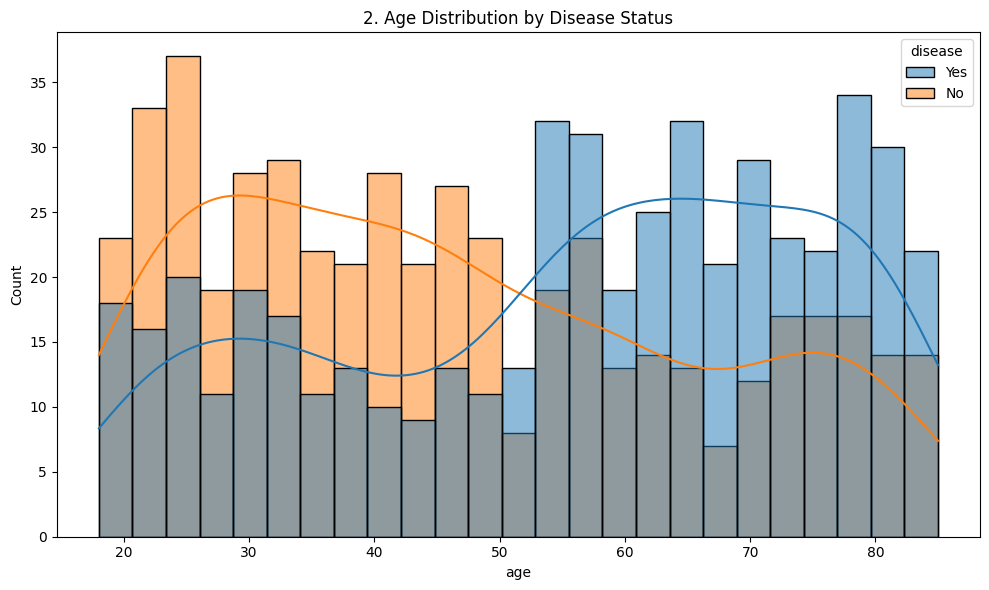

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age', hue='disease', kde=True, bins=25)
plt.title(f'{plot_no}. Age Distribution by Disease Status')
show_fig()
plot_no += 1

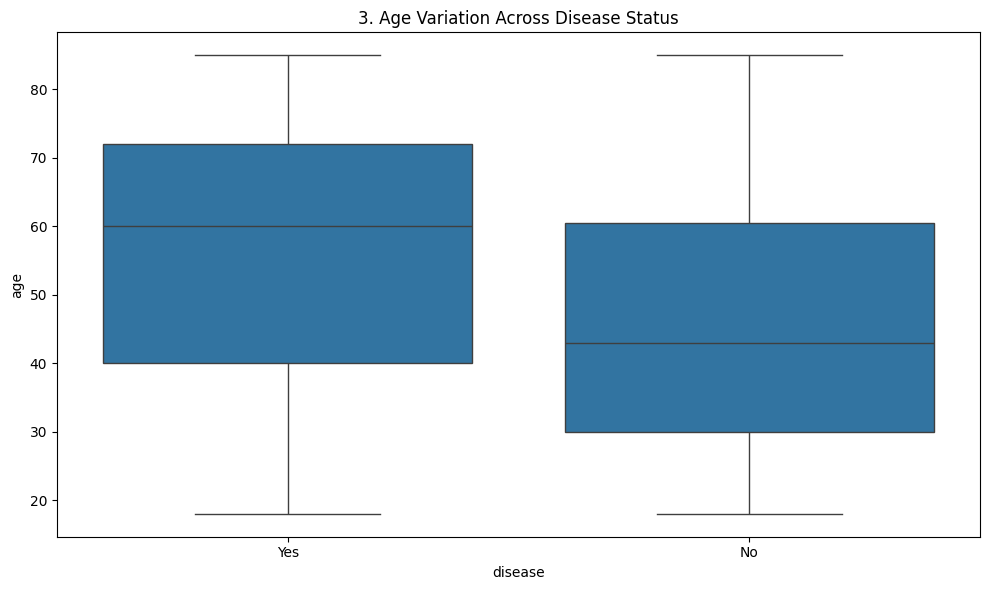

In [15]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='disease', y='age')
plt.title(f'{plot_no}. Age Variation Across Disease Status')
show_fig()
plot_no += 1

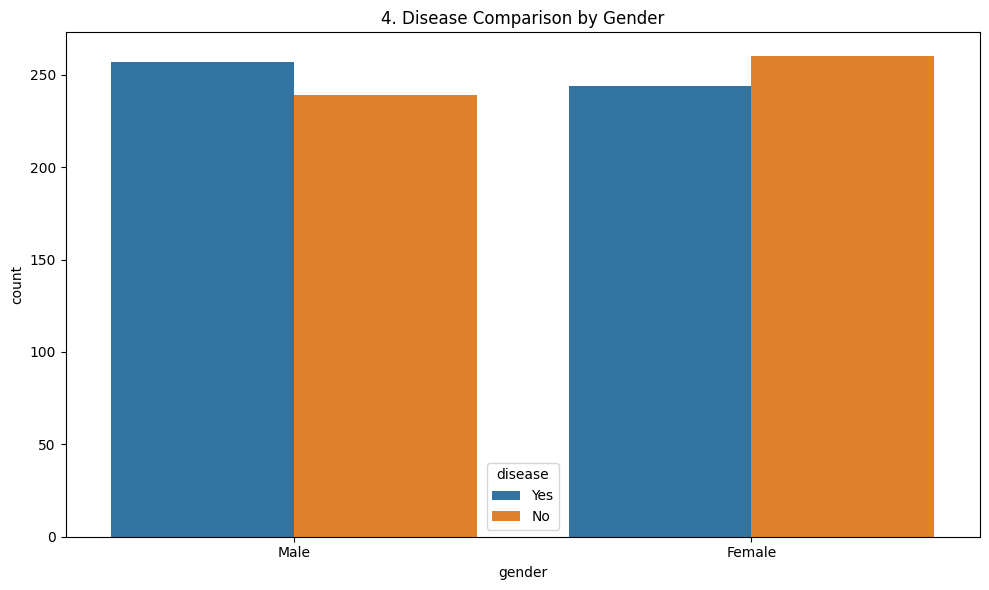

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='gender', hue='disease')
plt.title(f'{plot_no}. Disease Comparison by Gender')
show_fig()
plot_no += 1

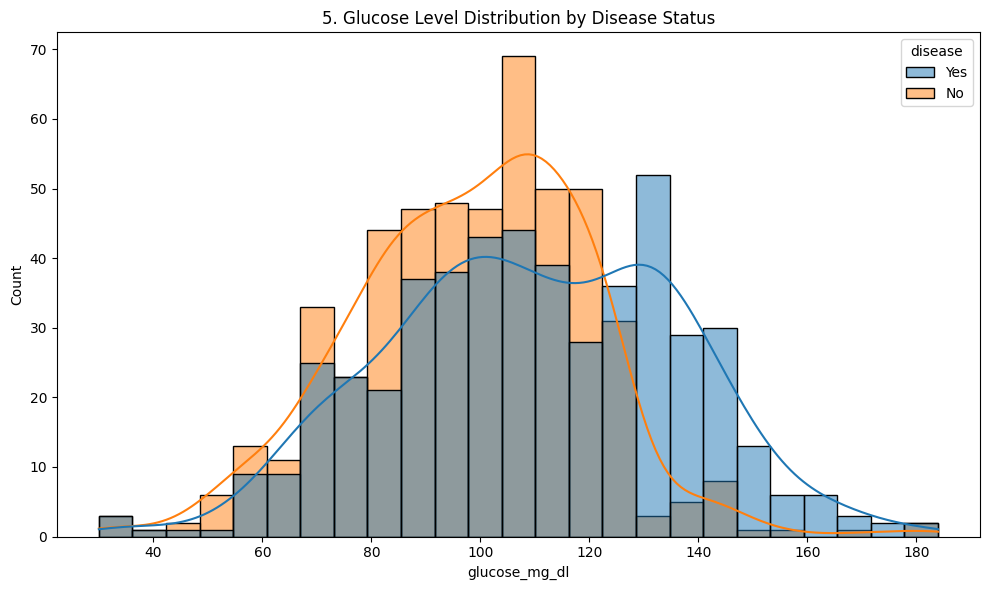

In [17]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='glucose_mg_dl', hue='disease', kde=True, bins=25)
plt.title(f'{plot_no}. Glucose Level Distribution by Disease Status')
show_fig()
plot_no += 1

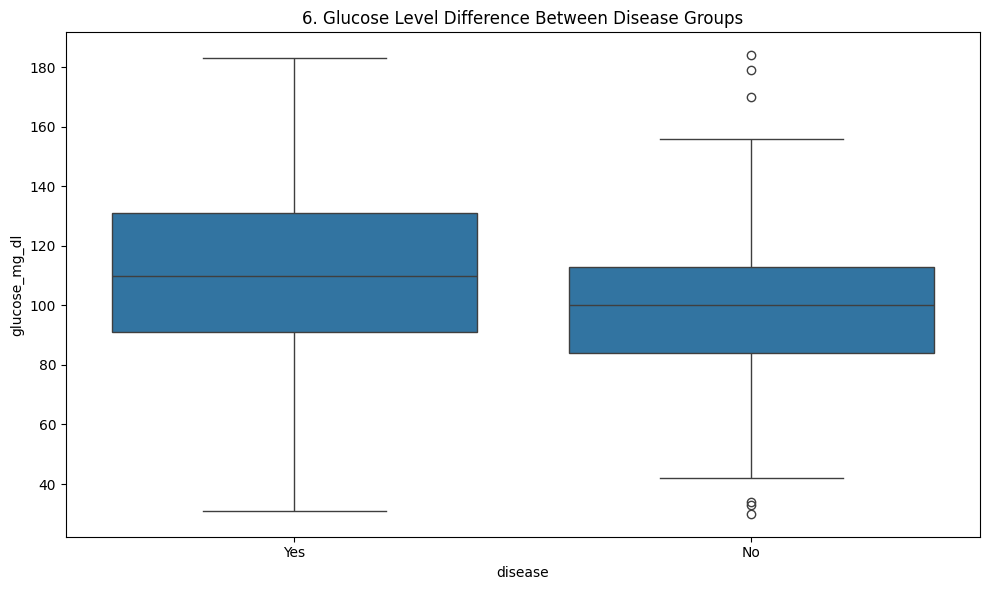

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='disease', y='glucose_mg_dl')
plt.title(f'{plot_no}. Glucose Level Difference Between Disease Groups')
show_fig()
plot_no += 1

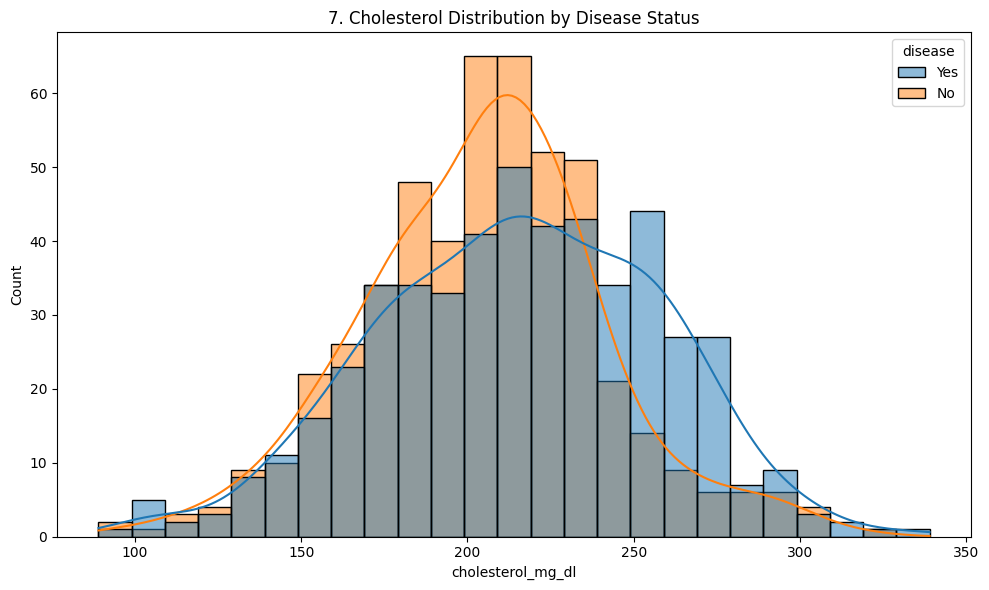

In [19]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='cholesterol_mg_dl', hue='disease', kde=True, bins=25)
plt.title(f'{plot_no}. Cholesterol Distribution by Disease Status')
show_fig()
plot_no += 1

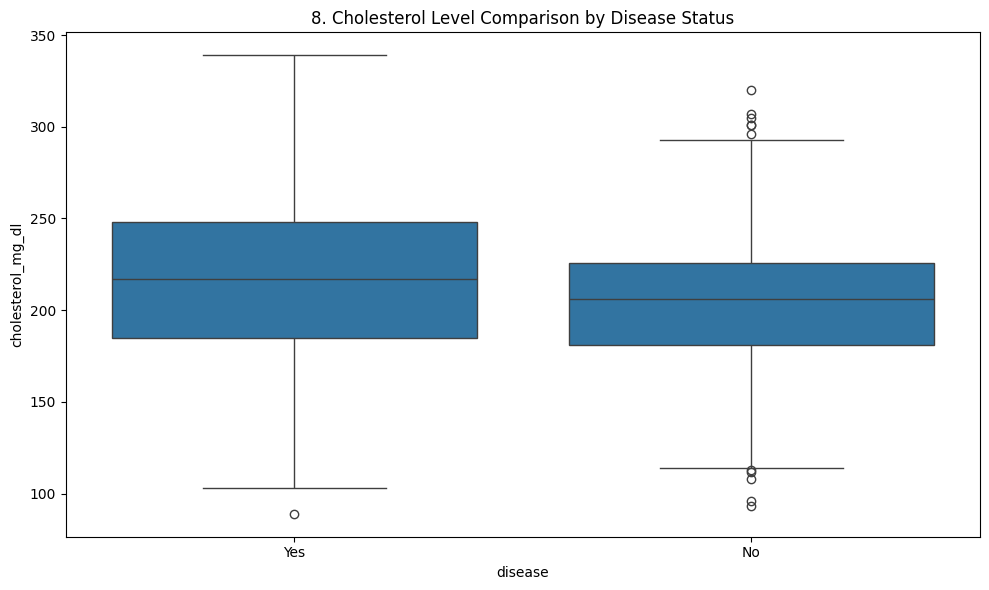

In [20]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='disease', y='cholesterol_mg_dl')
plt.title(f'{plot_no}. Cholesterol Level Comparison by Disease Status')
show_fig()
plot_no += 1

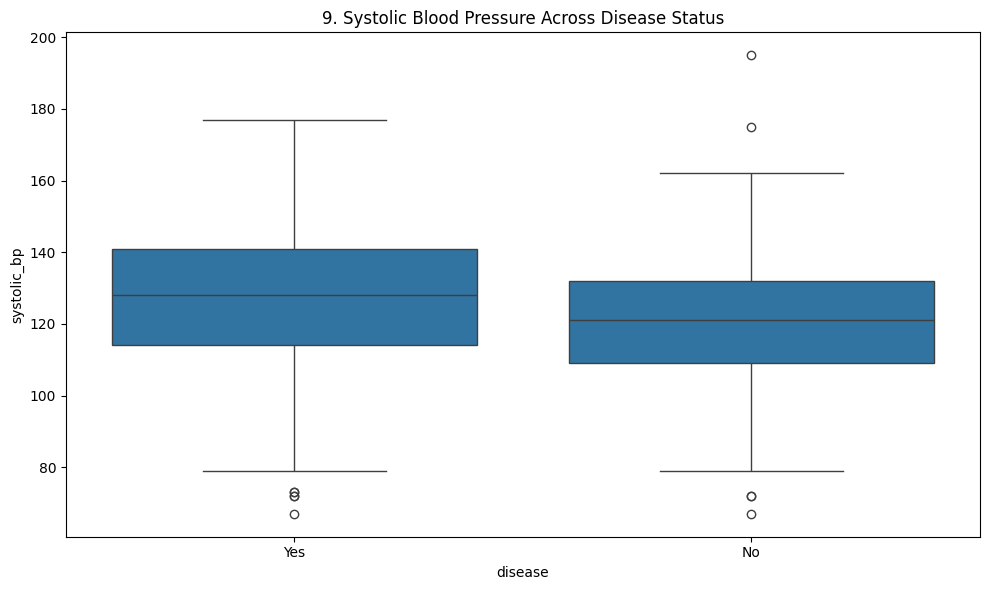

In [21]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='disease', y='systolic_bp')
plt.title(f'{plot_no}. Systolic Blood Pressure Across Disease Status')
show_fig()
plot_no += 1

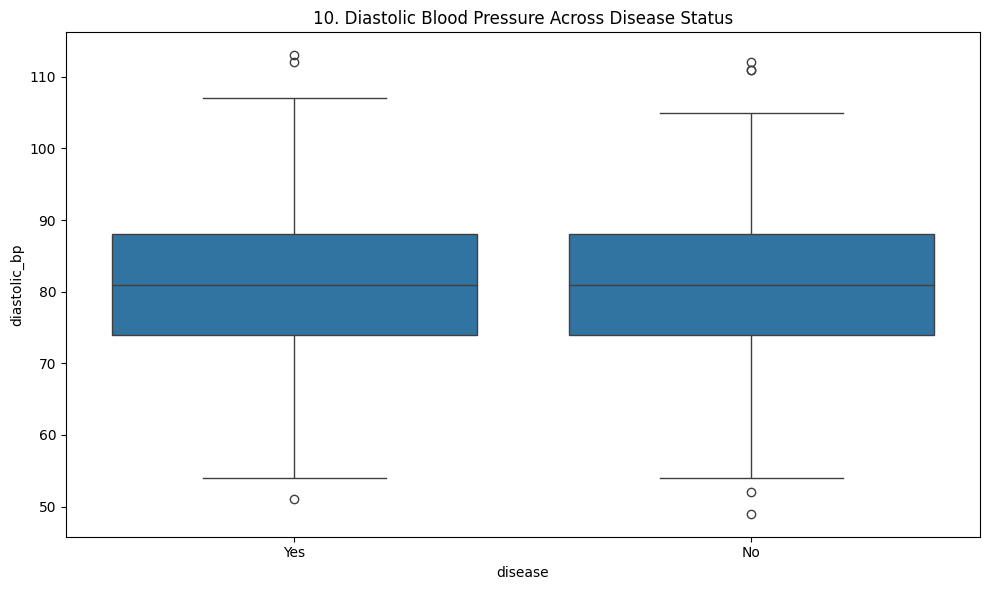

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='disease', y='diastolic_bp')
plt.title(f'{plot_no}. Diastolic Blood Pressure Across Disease Status')
show_fig()
plot_no += 1

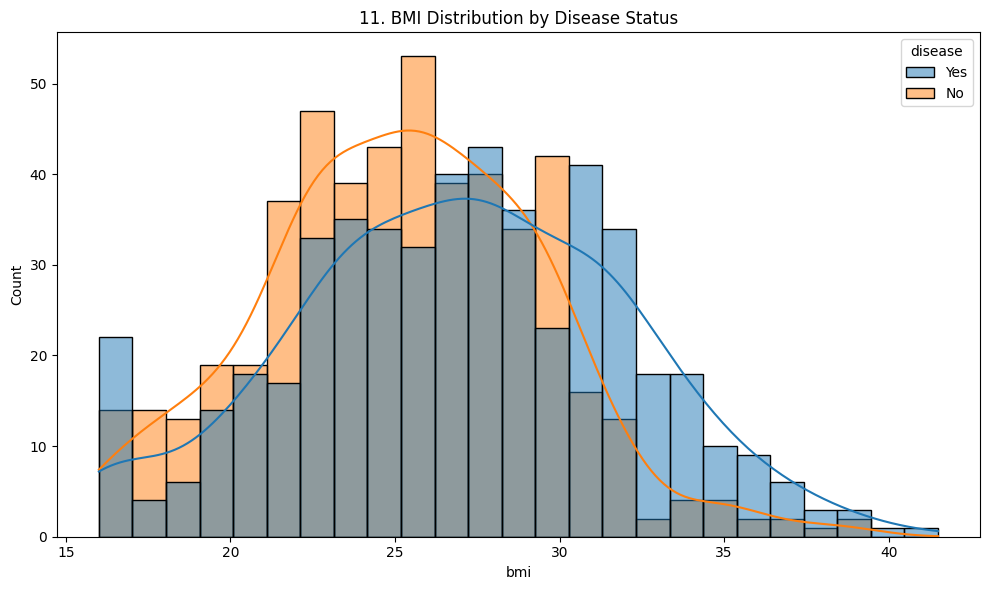

In [23]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='bmi', hue='disease', kde=True, bins=25)
plt.title(f'{plot_no}. BMI Distribution by Disease Status')
show_fig()
plot_no += 1

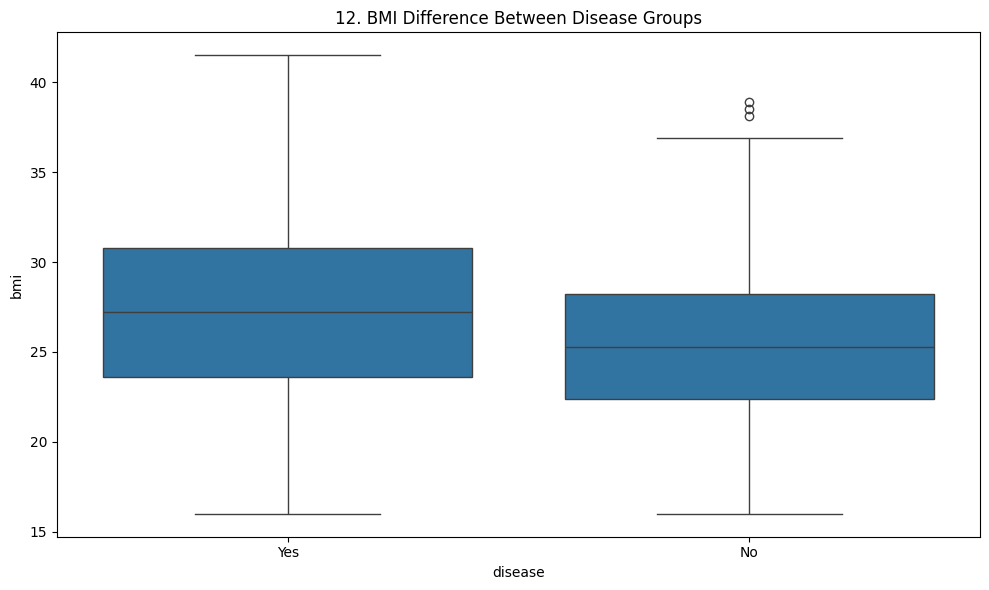

In [24]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='disease', y='bmi')
plt.title(f'{plot_no}. BMI Difference Between Disease Groups')
show_fig()
plot_no += 1

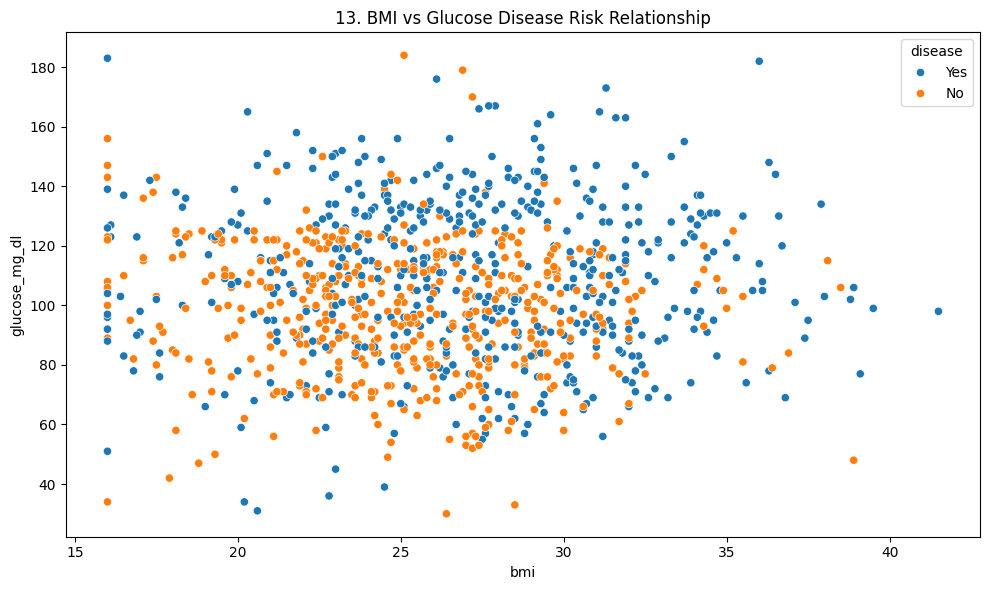

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='bmi', y='glucose_mg_dl', hue='disease')
plt.title(f'{plot_no}. BMI vs Glucose Disease Risk Relationship')
show_fig()
plot_no += 1

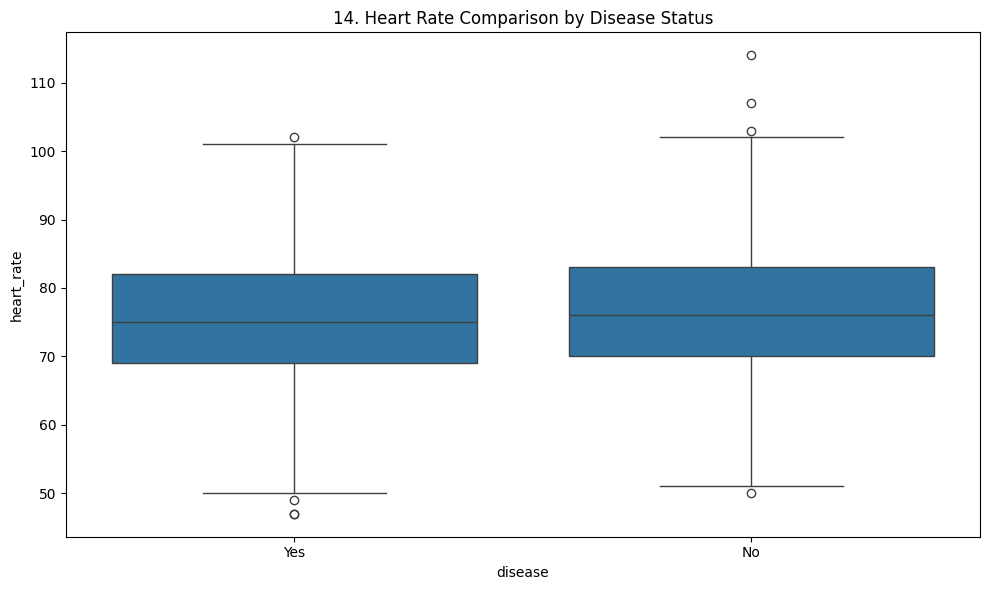

In [26]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='disease', y='heart_rate')
plt.title(f'{plot_no}. Heart Rate Comparison by Disease Status')
show_fig()
plot_no += 1

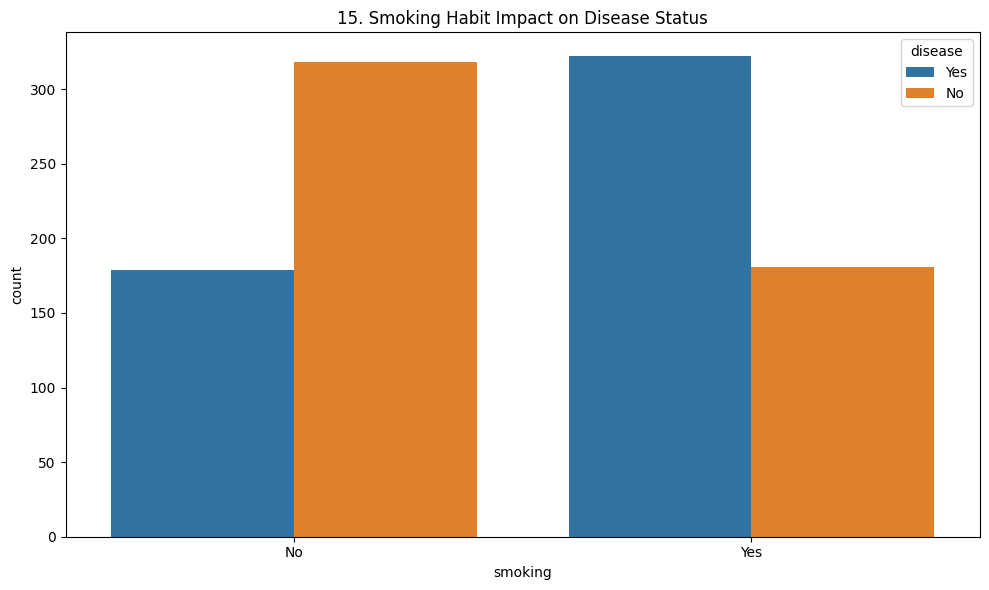

In [27]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='smoking', hue='disease')
plt.title(f'{plot_no}. Smoking Habit Impact on Disease Status')
show_fig()
plot_no += 1

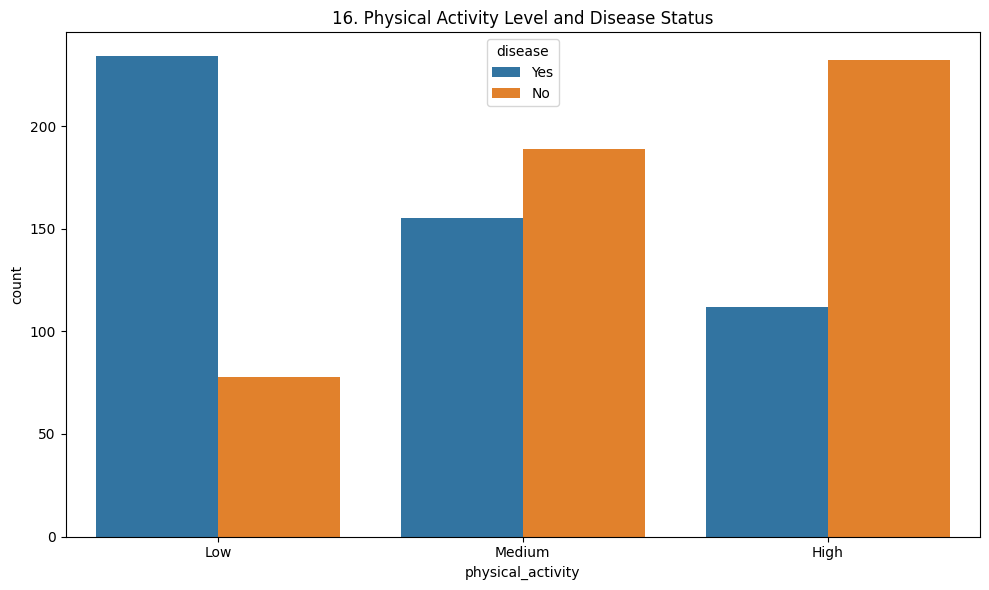

In [28]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='physical_activity', hue='disease', order=['Low', 'Medium', 'High'])
plt.title(f'{plot_no}. Physical Activity Level and Disease Status')
show_fig()
plot_no += 1

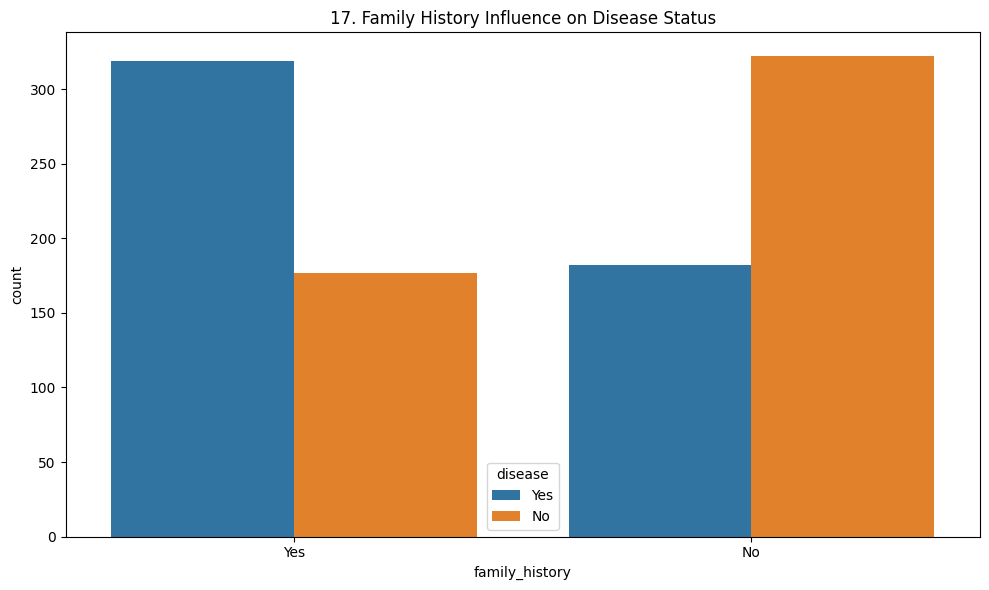

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='family_history', hue='disease')
plt.title(f'{plot_no}. Family History Influence on Disease Status')
show_fig()
plot_no += 1

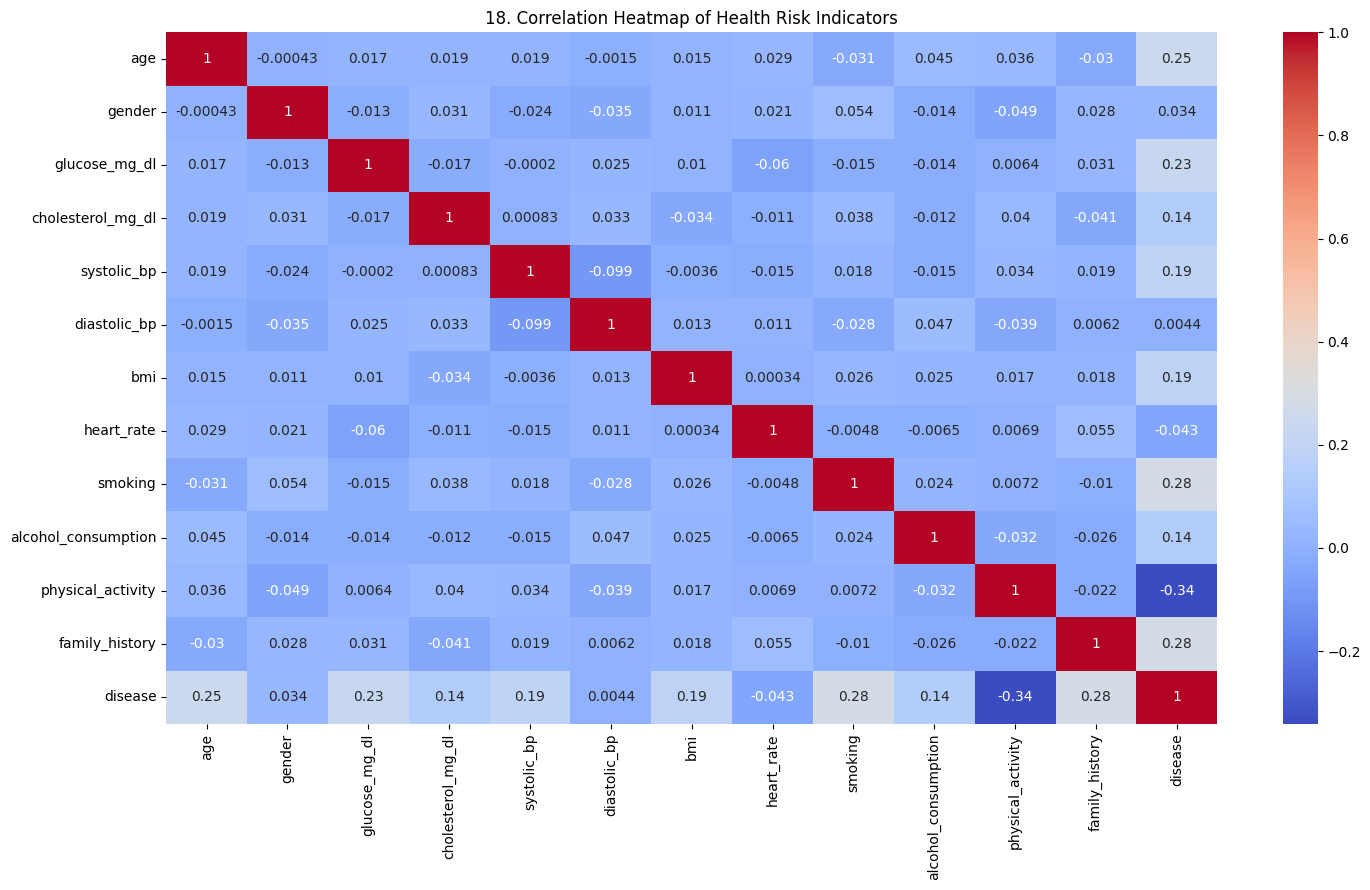

In [30]:
fig = plt.figure(figsize=(15, 9))
corr = df.copy()
corr['gender'] = corr['gender'].map({'Male': 1, 'Female': 0})
corr['smoking'] = corr['smoking'].map({'Yes': 1, 'No': 0})
corr['alcohol_consumption'] = corr['alcohol_consumption'].map({'Yes': 1, 'No': 0})
corr['physical_activity'] = corr['physical_activity'].map({'Low': 0, 'Medium': 1, 'High': 2})
corr['family_history'] = corr['family_history'].map({'Yes': 1, 'No': 0})
corr['disease'] = corr['disease'].map({'Yes': 1, 'No': 0})
corr = corr.drop(columns=['patient_id']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Health Risk Indicators')
show_fig()
plot_no += 1

# Model Training

## Create copy of dataframe

In [31]:
data = df.copy()

## Select target column

In [32]:
target = 'disease'

## Separate input and output

In [33]:
X = data.drop(columns=[target])
y = data[target]

## Find categorical and numerical columns

In [34]:
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

## Create preprocessing pipeline

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ]
)

## Create Gradient Boosting model

In [36]:
model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    random_state=42
)

## Create full training pipeline

In [37]:
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

## Split data into train and test

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Train model

In [39]:
pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Predict test data

In [40]:
y_pred = pipe.predict(X_test)

## Print accuracy score

In [41]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.945


## Print classification report

In [42]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

          No       0.94      0.95      0.95       100
         Yes       0.95      0.94      0.94       100

    accuracy                           0.94       200
   macro avg       0.95      0.94      0.94       200
weighted avg       0.95      0.94      0.94       200



## Create confusion matrix

In [43]:
cm = confusion_matrix(y_test, y_pred)

## Plot confusion matrix

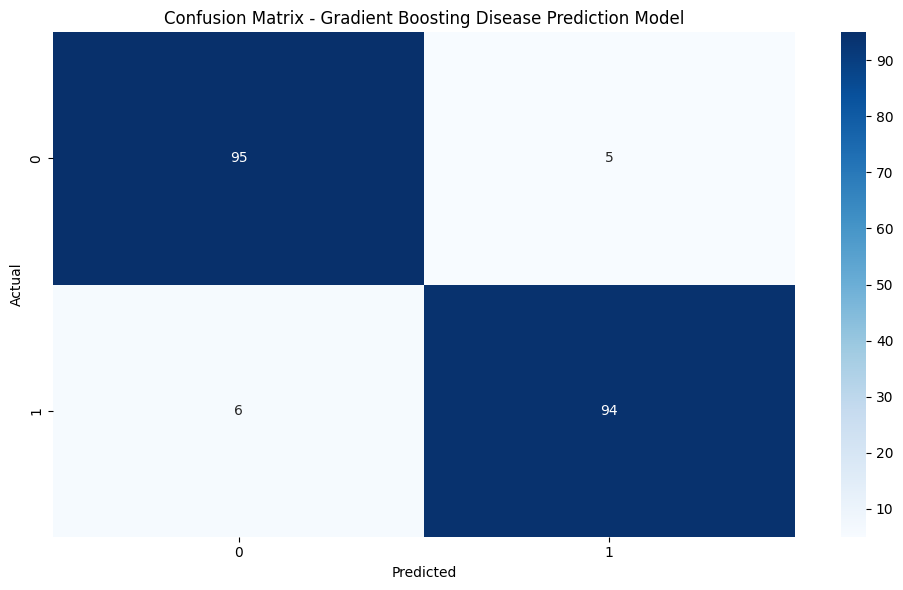

In [44]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Gradient Boosting Disease Prediction Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()